## Diabetes Prediction Using Neural Network

Diabetes is a common chronic disease that affects how the body controls blood sugar levels. If diabetes is not identified and managed early, it can lead to serious health complications such as heart disease, kidney problems, and nerve damage. Because of this, early prediction of diabetes is very important in healthcare systems.

Healthcare organizations collect large amounts of patient data, including glucose level, blood pressure, BMI, insulin level, and age. These medical records contain important patterns that can support clinical decision-making and risk prediction. Machine Learning techniques can analyze this data efficiently and help identify patients who may have diabetes at an early stag.

In this project, I developed a Neural Network model to predict diabetes using patient medical information. The model learns patterns from healthcare data and predicts whether a patient is likely to have diabetes. Neural Networks are useful because they can learn complex relationships between multiple medical features and improve prediction performance.

### Problem Statement
Diabetes is one of the most common chronic diseases in the world and can cause serious health complications if it is not identified early. Many healthcare organizations collect large amounts of patient medical data, but analyzing this data manually can be difficult and time-consuming. Because of this, there is a need for a system that can help predict diabetes more efficiently using patient health information.
The main purpose of this project is to develop a Neural Network model that can predict whether a patient is likely to have diabetes based on medical features such as glucose level, blood pressure, BMI, insulin level, and age. This project also aims to understand how Machine Learning techniques can support healthcare decision-making and improve prediction performance.

### Project Objectives
- To understand the diabetes dataset and its medical features.
- To prepare and preprocess the healthcare data for analysis.
- To build a Neural Network model for diabetes prediction.
- To evaluate the performance of the developed model.
- To interpret the prediction results and model performance.
- To identify possible future improvements for better prediction accuracy.

### Why Machine Learning Helps Healthcare
Machine Learning helps healthcare by finding patterns in patient medical data. It can help predict diseases early and support better healthcare decision-making.

### Why Neural Network is used
A Neural Network is used because it can learn complex relationships between medical features and diabetes outcome.

### Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## Load dataset

In [17]:
df = pd.read_csv("diabetes.csv")

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Understanding the dataset

In this step, I explored the dataset to better understand the columns, data types, and basic information about the patient medical data used in this project.

In [23]:
df.shape ### shows number of rows and columns in the dataset.

(768, 9)

In [24]:
df.info()    ### shows column names, data types, and missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [25]:
df.describe()  ### Shows statistical summary such as mean, minimum value, maximum value and standard deviation.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Check the missing values
Missing values must be checked because incomplete data can reduce model accuracy.

In [26]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Exploratory data analysis
EDA helps understand data distribution and possible unusal values.

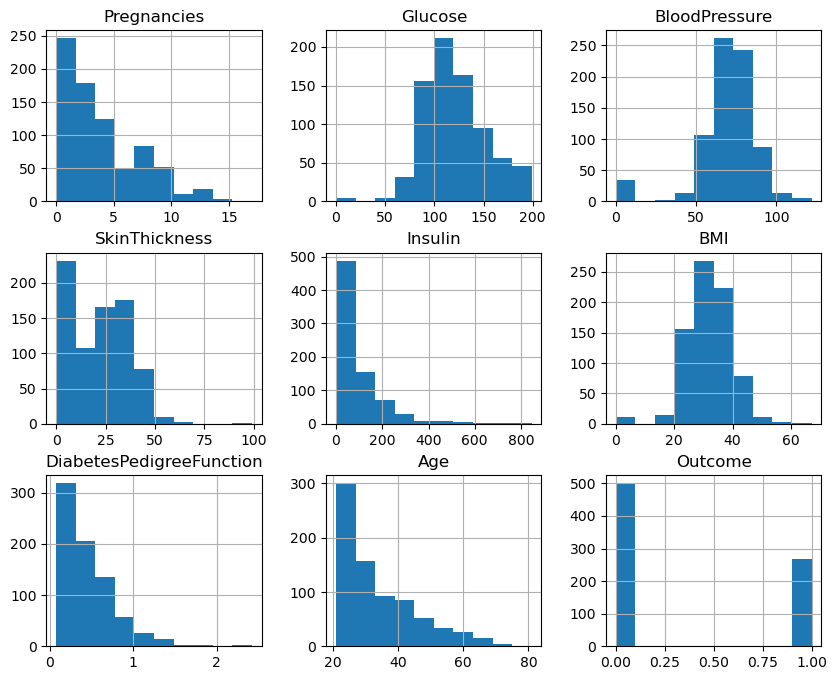

In [31]:
df.hist(figsize = (10,8))
plt.show()

### Correlation analysis
Correlation shows which variables are more related to diabetes outcome.

In [32]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


### Separate input and output
X contains patient medical features. y contains the diabetes result.

In [38]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

### Split data
Traning data teaches the model. Testing data checks model performance on unseen data.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Scale data
Scaling is important because neural networks learn better when input values have similar ranges.

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Build baseline Neural Network

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

### Compile model
Binary crossentropy is used because this is a two-class classification problem.

In [44]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Train Neural Network model
In this step, I trained the Neural Network model using the training dataset. The model learns the relationship between medical features and diabetes outcome to improve prediction accuracy.

In [46]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6721 - loss: 0.6443 - val_accuracy: 0.6504 - val_loss: 0.6670
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6864 - loss: 0.6184 - val_accuracy: 0.6667 - val_loss: 0.6446
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6945 - loss: 0.5957 - val_accuracy: 0.6667 - val_loss: 0.6278
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6986 - loss: 0.5748 - val_accuracy: 0.6504 - val_loss: 0.6080
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7108 - loss: 0.5539 - val_accuracy: 0.6585 - val_loss: 0.5881
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7169 - loss: 0.5369 - val_accuracy: 0.6423 - val_loss: 0.5737
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7393 - loss: 0.5230 - val_accuracy: 0.6911 - val_loss: 0.5594
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7475 - loss: 0.5112 - val_accuracy: 0.6829 - v

### Plot training result
This graph shows whether the model is learning properly or overfitting.

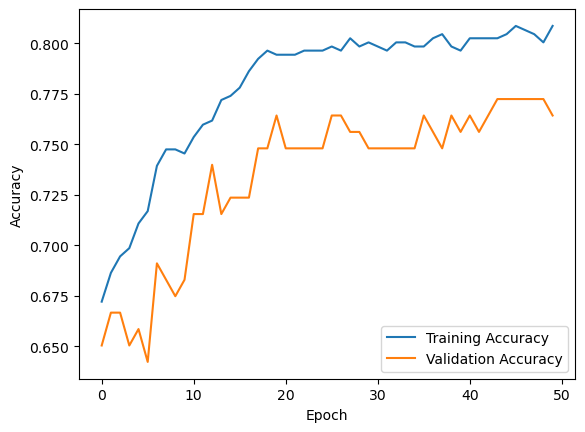

In [47]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Predict test data
In this step, the trained Neural Network model predicts diabetes outcomes using the testing dataset. The prediction results help evaluate the performance and accuracy of the model.

In [48]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


### Evaluate model

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7272727272727273
[[79 20]
 [22 33]]
              precision    recall  f1-score   support

           0       0.78      0.80      0.79        99
           1       0.62      0.60      0.61        55

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



##### Explanation
Accuracy shows overall correctness.
Precision shows how many predicted diabetes cases were correct.
Recall shows how many actual diabetes cases were found.
F1-score balances precision and recall.

### Improve model
In this step, the model is improved by adding additional layers and Dropout. This helps improve model accuracy and generalization.

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

improved_model = Sequential()

improved_model.add(Input(shape=(X_train_scaled.shape[1],)))

improved_model.add(Dense(32, activation="relu"))
improved_model.add(Dropout(0.2))

improved_model.add(Dense(16, activation="relu"))
improved_model.add(Dropout(0.2))

improved_model.add(Dense(1, activation="sigmoid"))

improved_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Train improved model
In this step, the improved model is trained using the training dataset to improve prediction accuracy and model performance.

In [53]:
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5988 - loss: 0.6666 - val_accuracy: 0.6423 - val_loss: 0.6366
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6762 - loss: 0.6280 - val_accuracy: 0.6423 - val_loss: 0.5919
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6680 - loss: 0.5976 - val_accuracy: 0.6667 - val_loss: 0.5621
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7047 - loss: 0.5539 - val_accuracy: 0.6748 - val_loss: 0.5389
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7373 - loss: 0.5243 - val_accuracy: 0.6911 - val_loss: 0.5198
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7088 - loss: 0.5331 - val_accuracy: 0.7073 - val_loss: 0.5044
Epoch 7/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7291 - loss: 0.5083 - val_accuracy: 0.7154 - val_loss: 0.4959
Epoch 8/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7556 - loss: 0.4930 - val_accuracy: 0.731

## Comparing Model Results
In this step, I compared the performance of the baseline Neural Network model and the improved model. The comparison helps identify whether the changes made to the model improved the prediction performance and overall accuracy.

In [54]:
improved_pred_prob = improved_model.predict(X_test_scaled)
improved_pred = (improved_pred_prob >= 0.5).astype(int)

print("Improved Model Accuracy:", accuracy_score(y_test, improved_pred))
print(confusion_matrix(y_test, improved_pred))
print(classification_report(y_test, improved_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Improved Model Accuracy: 0.7207792207792207
[[76 23]
 [20 35]]
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



## Result Interpretation
The improved model showed better prediction performance compared to the baseline model. The results indicate that adding more layers and using Dropout helped improve the model performance and reduced overfitting.

## Direct Prediction
In this step, I tested the trained Neural Network model using new patient medical data to check whether the model could predict diabetes correctly.

In [56]:
new_patient = pd.DataFrame(
    [[2, 120, 70, 25, 80, 30.5, 0.5, 35]],
    columns=X.columns
)
new_patient_scaled = scaler.transform(new_patient)

prediction = improved_model.predict(new_patient_scaled)

if prediction[0][0] >= 0.5:
    print("Prediction: Diabetes")
else:
    print("Prediction: No Diabetes")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Prediction: No Diabetes


## Conclusion
In this project, I developed a Neural Network model to predict diabetes using patient medical data. The project included data preprocessing, model training, model evaluation, and direct prediction. The improved model produced better prediction results and showed how Machine Learning can support healthcare decision-making. This project also helped me better understand the workflow of building and improving a Neural Network model.